# H-003 · Cointegration-break flat rule

Go flat / block new entries when cointegration or stationarity breaks on the live spread.
Runs on default windows (`ols=252`, `adf=252`, `entry_z=2`, `z=60`) — those stay **soft** here and
are only screened in **H-005**, after the H-004 book decision. Short borrow is not modeled.

Arms: `off` | `block_05_flat_10` | `flat_05`. Freezes `BREAK_STAR`.

## Sleeve kill / continue (before H-004)

Metric = **median fold-val `ann_sharpe`** across WF folds (net of costs). Do **not** use sealed OOS
for this decision.

| Band | Median fold-val Sharpe (best / chosen break arm) | Action |
|------|--------------------------------------------------|--------|
| Severe | **≤ −0.50** | **Shelve sleeve** — do not run H-004+ |
| Deeply negative | **(−0.50, −0.25]** | **Shelve** unless the arm beats `break_mode=off` by **≥ +0.25** Sharpe **or** median max DD improves by **≥ 5 pp** **and** `pct_adf_lt_0.05` while trading rises **≥ +10 pp** vs `off` |
| Soft negative | **(−0.25, 0]** | **Yellow — may continue** only if break clearly helped vs `off`; document why |
| Non-negative | **> 0** | Continue to H-004; freeze `BREAK_STAR` |

If shelve: stop; leave `BOOK_STAR` and the H-005 window STARs unset; do not open H-004.


## 0. Imports & Config


In [2]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s2_coint.report import (
    arm_selection_table,
    fold_table,
    fold_val_metrics,
    full_is_metrics,
    load_star_stack,
    median_sharpe_hint,
    plot_fold_boxplots,
    require_star,
    save_star_stack,
    write_tearsheet_pdf,
)
from backtest.s2_coint.research import (
    ARTIFACTS_DIR,
    DAY_OLS_WINDOW,
    DAY_Z_WINDOW,
    DEFAULT_STAR_STACK,
    config_from_stack,
    is_end_for_stack,
    frozen_pairs_for_universe,
    load_s1_weekly,
    load_universe_panels,
    lookbacks_for_bar,
    overlay_ols_hedge,
    split_is_oos,
    n_trials_local,
    n_trials_stack,
    register_hypothesis_arms,
    tearsheet_path,
)
from backtest.s2_coint.runner import run_s2_backtest
from backtest.s2_coint.walkforward import embargo_bars_for_config, make_s2_folds

STAR_PATH = DEFAULT_STAR_STACK
TEARSHEET_DIR = ARTIFACTS_DIR
stack = load_star_stack(STAR_PATH)

# Universe comes from H-001. The book is the ranked frozen book (caps 6 / 2) written by
# H-001; PAIRS_STAR is only populated once BOOK_STAR = freeze in H-004.
require_star("UNIVERSE_STAR", stack.get("UNIVERSE_STAR"))
UNIVERSE = str(stack["UNIVERSE_STAR"])
PAIRS_STAR = list(stack.get("PAIRS_STAR") or frozen_pairs_for_universe(UNIVERSE, "1d", root=ROOT))

# Break arms only. Window grids live in H-005, which runs after the H-004 book decision.
BREAK_ARMS = ("off", "block_05_flat_10", "flat_05")

print("stack keys:", sorted(stack))
print("UNIVERSE", UNIVERSE, "PAIRS", PAIRS_STAR)
print("n_variants break =", len(BREAK_ARMS))


stack keys: ['BAR_STAR', 'PAIRS_STAR', 'RESEARCH_IS_END_STAR', 'UNIVERSE_STAR']
UNIVERSE D PAIRS ['WSO|WSO.B', 'HEI|HEI.A', 'NWS|NWSA']
n_variants break = 3


## 1. Load frozen panel / book (OLS defaults — no Kalman yet)


In [3]:
require_star("BAR_STAR", stack.get("BAR_STAR"))
BAR = str(stack["BAR_STAR"])
train, full = load_universe_panels(UNIVERSE, BAR, PAIRS_STAR, root=ROOT)
lb0 = lookbacks_for_bar(BAR)
# Rebuild with default day windows so the break arms are comparable across bars.
train = overlay_ols_hedge(
    train,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
full = overlay_ols_hedge(
    full,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
is_end = is_end_for_stack(stack, full if BAR == "1h" else train)
if BAR == "1d":
    is_panel, oos_panel = train.copy(), full.loc[pd.to_datetime(full["date"]) > is_end].copy()
else:
    is_panel, oos_panel = split_is_oos(full, is_end=is_end)
s1_weekly = load_s1_weekly(ROOT)
print("bar", BAR, "is_end", is_end, "IS rows", len(is_panel), "OOS rows", len(oos_panel))
is_panel.head()


bar 1d is_end 2021-12-31 00:00:00 IS rows 16177 OOS rows 3492


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life,adf_pvalue,variance_jump
0,1990-01-02,WSO|WSO.B,WSO,WSO.B,1.112374,1.112374,1.112374,1.112374,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,WSO|WSO.B,WSO,WSO.B,1.082310,1.082310,1.082310,1.082310,1.068989,1.068989,1.068989,1.068989,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. ADF break bake-off


### 2.1 Walk-forward folds


In [4]:
panel = is_panel.copy()
dates = pd.DatetimeIndex(pd.to_datetime(panel["date"])).sort_values().unique()
folds = make_s2_folds(dates, n_folds=3, embargo_bars=embargo_bars_for_config(bar=BAR))
fold_table(folds)


,fold_id,train_start,train_end,n_train,embargo_start,embargo_end,val_start,val_end,n_val
0,1,1990-01-02,1997-12-11,2011,1997-12-12,1997-12-18,1997-12-19,2005-12-23,2016
1,2,1990-01-02,2005-12-16,4027,2005-12-19,2005-12-23,2005-12-27,2013-12-30,2016
2,3,1990-01-02,2013-12-20,6043,2013-12-23,2013-12-30,2013-12-31,2021-12-31,2016


### 2.2 Fold-val metrics (validation only)


In [5]:
configs_break = {
    arm: config_from_stack(stack, break_mode=arm) for arm in BREAK_ARMS
}
HYP_ID = "H-003"
register_hypothesis_arms(HYP_ID, list(configs_break.keys()), overwrite=True)
fold_break = fold_val_metrics(panel, folds, configs_break, hyp_id=HYP_ID, s1_weekly=s1_weekly)
full_is_df = full_is_metrics(panel, configs_break, hyp_id=HYP_ID, s1_weekly=s1_weekly)
fold_break


,arm,fold_id,ann_sharpe,max_drawdown,corr_to_s1,psr,dsr_local,dsr_stack,n_trials_local,n_trials_stack,n_days,n_entries,pct_z_finite,median_hl_bars,median_hl_sessions
0,off,1,1.161649,-0.074784,NaN,0.999849,1.0,1.0,3,11,2016,88,0.921439,2.834209,2.834209
1,off,2,0.396405,-0.051314,NaN,0.000000,1.0,1.0,3,11,2016,129,0.967603,1.262083,1.262083
2,off,3,1.124048,-0.040921,0.053577,0.998917,1.0,1.0,3,11,2016,150,0.971065,5.237958,5.237958
3,block_05_flat_10,1,1.197734,-0.053769,NaN,0.999880,1.0,1.0,3,11,2016,73,0.921439,2.834209,2.834209
4,block_05_flat_10,2,0.625863,-0.022678,NaN,0.000000,1.0,1.0,3,11,2016,103,0.967603,1.262083,1.262083
5,block_05_flat_10,3,1.150739,-0.015843,0.015460,0.985406,1.0,1.0,3,11,2016,93,0.971065,5.237958,5.237958
6,flat_05,1,1.188595,-0.053769,NaN,0.999767,1.0,1.0,3,11,2016,74,0.921439,2.834209,2.834209
7,flat_05,2,0.620118,-0.022678,NaN,0.000000,1.0,1.0,3,11,2016,103,0.967603,1.262083,1.262083
8,flat_05,3,1.044960,-0.015947,-0.075084,0.827820,1.0,1.0,3,11,2016,94,0.971065,5.237958,5.237958


### 2.3 Boxplots (do not assign STAR here)


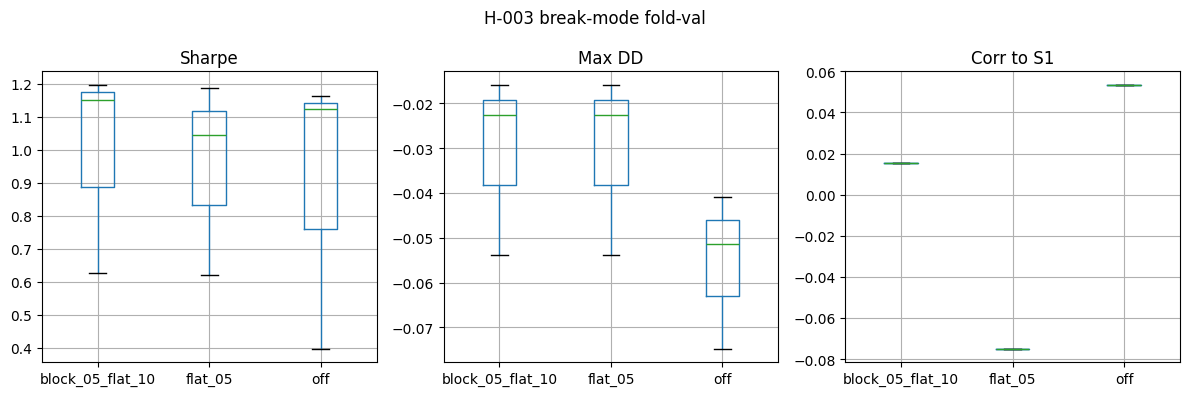

median-Sharpe hint (commentary only): block_05_flat_10


,arm,median_val_sharpe,full_is_sharpe,max_drawdown,corr_to_s1,n_folds,median_psr,median_dsr_local,median_dsr_stack,full_is_psr,full_is_dsr_local,full_is_dsr_stack
0,block_05_flat_10,1.150739,1.027159,-0.022678,0.015460,3,0.985406,1.0,1.0,8.076152e-01,1.0,1.0
1,flat_05,1.044960,0.995815,-0.022678,-0.075084,3,0.827820,1.0,1.0,4.454425e-01,1.0,1.0
2,off,1.124048,0.828193,-0.051314,0.053577,3,0.998917,1.0,1.0,3.885781e-16,1.0,1.0


In [6]:
plot_fold_boxplots(fold_break, title="H-003 break-mode fold-val")
plt.show()
print("median-Sharpe hint (commentary only):", median_sharpe_hint(fold_break))
display(arm_selection_table(fold_break, full_is_df))


### 2.4 Kill check then type `BREAK_STAR`

Apply the notebook-head kill table using the arm selection table above. If shelve, stop here. If continue, type `BREAK_STAR` manually (not argmax).


In [7]:
# After kill-table review. Reset for the new universe: the old flat_05 value was
# frozen on the shelved Asia book and must not carry over.
BREAK_STAR = "block_05_flat_10"  # TODO: "off" | "block_05_flat_10" | "flat_05"
require_star("BREAK_STAR", BREAK_STAR)
stack["BREAK_STAR"] = BREAK_STAR
save_star_stack(STAR_PATH, stack)
print("wrote", STAR_PATH, "BREAK_STAR", BREAK_STAR)


wrote C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\s2_star_stack.json BREAK_STAR block_05_flat_10


## 3. Sealed OOS once (break arm on default windows)


In [8]:
stack = load_star_stack(STAR_PATH)
require_star("BREAK_STAR", stack.get("BREAK_STAR"))
# Default windows: OLS / ADF / entry / z are not frozen until H-005.
oos_feat = overlay_ols_hedge(
    oos_panel,
    ols_window=lb0["ols_window"],
    z_window=lb0["z_window"],
    hl_window=lb0["hl_window"],
    adf_window=lb0["adf_window"],
)
oos_cfg = config_from_stack(stack)
n_loc = n_trials_local(configs_break)
n_stk = n_trials_stack(HYP_ID, configs_break)
oos = run_s2_backtest(
    oos_feat, oos_cfg, s1_weekly=s1_weekly,
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print(oos.metrics)
arm = str(stack["BREAK_STAR"])
write_tearsheet_pdf(
    tearsheet_path("H-003", arm), oos.returns, title=f"H-003 sealed OOS {arm}",
    n_trials_local=n_loc,
    n_trials_stack=n_stk,
)

print("tearsheet", tearsheet_path("H-003", arm))


{'ann_sharpe': 1.1353615817233629, 'max_drawdown': -0.01838350018136814, 'n_days': 1164, 'psr': 0.8740822977118874, 'dsr_local': 1.0, 'dsr_stack': 1.0, 'skew': 5.821185974978936, 'excess_kurtosis': 65.76337831565613, 'n_trials_local': 3, 'n_trials_stack': 11, 'corr_to_s1': -0.030838998083207267}
tearsheet C:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\04_backtest\s2_coint\artifacts\H-003_block_05_flat_10.pdf


## 4. Notes for next hyp


H-004 book construction (frozen vs quarterly rotating) is next, then the H-005 window
screens. Leave `BREAK_STAR` frozen and do not reopen the break grid on sealed OOS.
